## Importing Libraies 

In [4]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np 
from sklearn.preprocessing import StandardScaler

## Loading Dataset

In [5]:
df = pd.read_csv("housing.csv")

In [7]:
(df.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [9]:

(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


## Data cleaning 

#### 1. Handling missing values 

In [10]:
# Check missing values
print(df.isnull().sum())


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [14]:

# Fill missing values in 'total_bedrooms' with median
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [15]:
print(df.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


#### 2. Removing Duplicates

In [17]:
# Check duplicates
print(df.duplicated().sum())

0


#### 3. Fixing Data Types

In [19]:
# Convert categorical column to string
df['ocean_proximity'] = df['ocean_proximity'].astype(str)

#### 4. Handling Outliers 

In [20]:
# Select numerical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

# Cap outliers using 1st and 99th percentiles
for col in num_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

In [21]:
print(df.shape)

(20640, 10)


In [22]:
print(df.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


## Saving cleaned dataset

In [24]:
df.to_csv("cleaned_housing.csv", index=False)
print("Cleaned dataset saved")

Cleaned dataset saved


## Creating new features

In [25]:
# Rooms per household
df['rooms_per_household'] = df['total_rooms'] / df['households']

# Bedrooms per room
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']

# Population per household
df['population_per_household'] = df['population'] / df['households']

## One hot encoding (categories into numbers)

In [26]:
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

## Feature Scaling 

In [29]:
scaler = StandardScaler()
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = scaler.fit_transform(df[num_cols])

In [32]:
(df.head())


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-1.346081,1.060350,0.982870,-0.920349,-1.080571,-1.112147,-1.087863,2.479625,2.130820,0.757940,-1.068275,-0.158536,False,False,True,False
1,-1.341022,1.050933,-0.608654,2.430626,1.556934,1.024755,1.917185,2.466431,1.314666,0.398392,-0.921413,-0.328095,False,False,True,False
2,-1.351141,1.046224,1.858207,-0.604056,-0.915896,-0.933301,-0.936423,1.887680,1.259157,1.386440,-1.340677,-0.064685,False,False,True,False
3,-1.356201,1.046224,1.858207,-0.708050,-0.794414,-0.869574,-0.811707,0.992779,1.165486,0.195584,-0.464161,-0.161432,False,False,True,False
4,-1.356201,1.046224,1.858207,-0.517844,-0.672932,-0.862379,-0.692931,-0.003348,1.173292,0.419462,-0.661385,-0.300847,False,False,True,False


In [33]:
print(df.shape)

(20640, 16)


In [34]:
print(df.head())
print(df.shape)

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0  -1.346081  1.060350            0.982870    -0.920349       -1.080571   
1  -1.341022  1.050933           -0.608654     2.430626        1.556934   
2  -1.351141  1.046224            1.858207    -0.604056       -0.915896   
3  -1.356201  1.046224            1.858207    -0.708050       -0.794414   
4  -1.356201  1.046224            1.858207    -0.517844       -0.672932   

   population  households  median_income  median_house_value  \
0   -1.112147   -1.087863       2.479625            2.130820   
1    1.024755    1.917185       2.466431            1.314666   
2   -0.933301   -0.936423       1.887680            1.259157   
3   -0.869574   -0.811707       0.992779            1.165486   
4   -0.862379   -0.692931      -0.003348            1.173292   

   rooms_per_household  bedrooms_per_room  population_per_household  \
0             0.757940          -1.068275                 -0.158536   
1             0.398392

I engineered new features such as ratios between rooms, households, and population, applied one-hot encoding to categorical variables, and standardized numerical features using StandardScaler to prepare the dataset for machine learning.

In [35]:
df.to_csv("engineered_housing.csv", index=False)

print("Engineered dataset saved")

Engineered dataset saved


## Exploratory Data Analysis (EDA)

#### Correlation heatmap

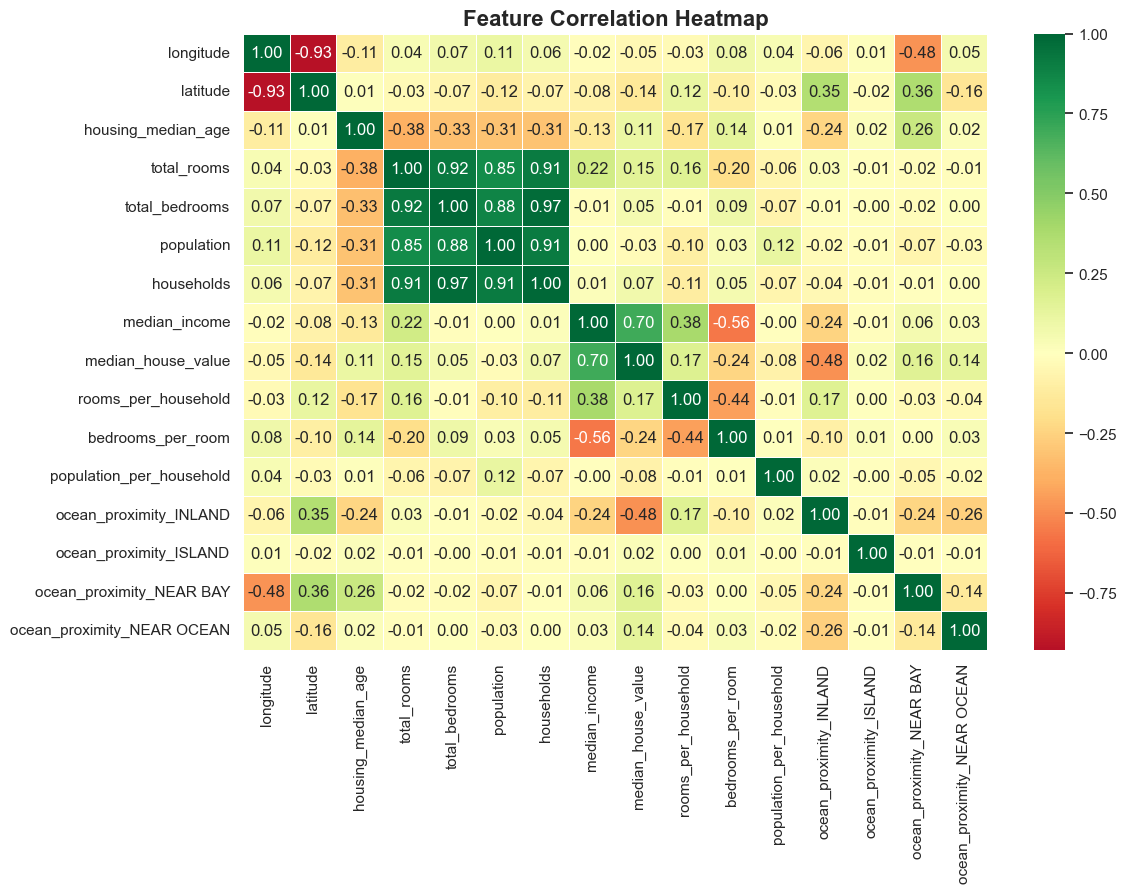

In [38]:
# Set style
sns.set(style="white")

# Create heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="RdYlGn",     # red → yellow → green 🔥
    center=0,          # highlight positive vs negative
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=16, fontweight='bold')

plt.show()

#### 1. House Prices drivers 
Median_income (0.70)
- When income goes up -> house prices go 
- Rooms_per_household (0.17)

More space per family → slightly higher house price. Example:
- 2 people in 6 rooms → comfortable → higher value
- 6 people in 6 rooms → crowded → lower value

Bedrooms_per_room (-0.24)
- Too many bedrooms compared to rooms → lower house value
- Why? It suggests small, cramped spaces


#### 2. Feature Relationships
Strong relationships (0.85 – 0.97):
- total_rooms
- total_bedrooms
- population
- households

More people → more rooms → more households

#### 3. Location Insights

Latitude & Longitude (weak relationship)
- Location matters, but not strongly by itself

INLAND (-0.48)
- Houses far from the ocean are cheaper

- NEAR OCEAN / NEAR BAY (positive)
Houses near water are more expensive

- Real-world :
People pay more for better views and location

#### 4. Engineered Features
Rooms_per_household
- Measures space per family
- More space = better living = higher price

Bedrooms_per_room
- Measures crowdedness
- Higher value = more crowded = cheaper houses

Population_per_household
- How many people live in each house
But It doesn’t affect price much

##### Insights
- House prices depend mostly on income, location, and how comfortable the living space is.
- The heatmap showed that income and location are the strongest drivers of house prices, while features like room distribution help explain living conditions

#### Distribution Analysis

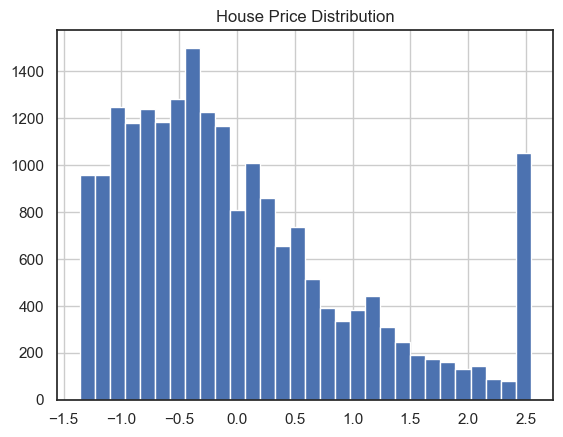

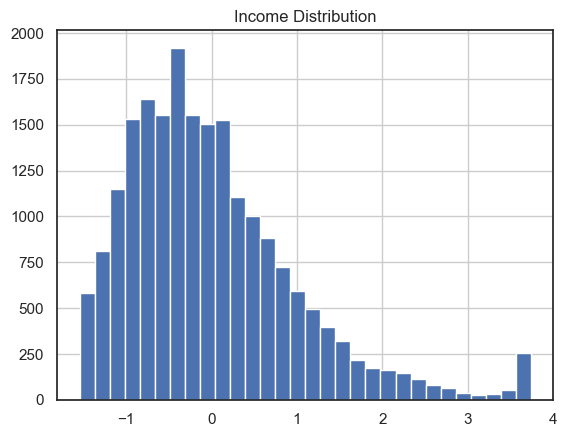

In [39]:
# Histogram 
df['median_house_value'].hist(bins=30)
plt.title("House Price Distribution")
plt.show()

df['median_income'].hist(bins=30)
plt.title("Income Distribution")
plt.show()

- Prices and income are right-skewed, indicating more lower-to-mid values and fewer high-value extremes.

##### Relationship Analysis

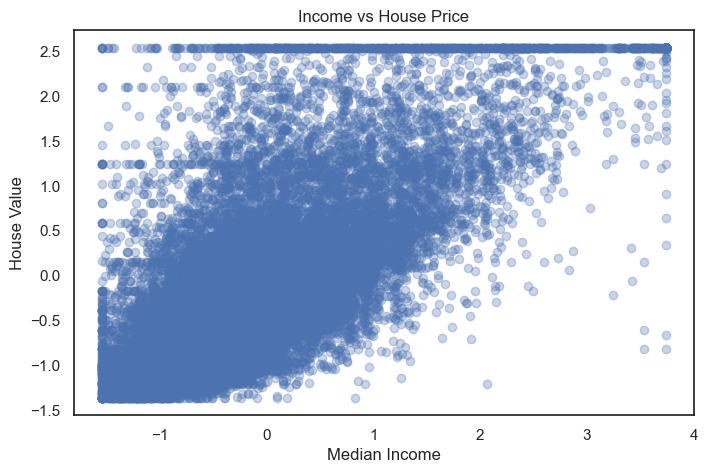

In [41]:
plt.figure(figsize=(8,5))

plt.scatter(df['median_income'], df['median_house_value'], alpha=0.3)

plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Income vs House Price")

plt.show()

- The scatter plot shows a clear positive relationship between median income and house prices, indicating that higher-income areas tend to have more expensive housing. The data was standardized, which explains the centered distribution around zero.

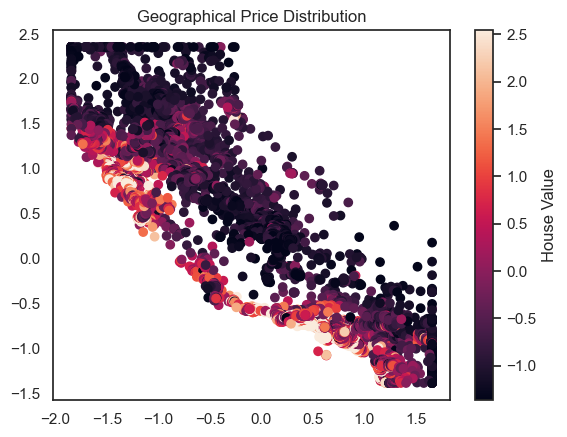

In [42]:
plt.scatter(df['longitude'], df['latitude'], c=df['median_house_value'])
plt.colorbar(label="House Value")
plt.title("Geographical Price Distribution")
plt.show()

#### Insights 
Coastal Areas Are More Expensive
- Brighter colors (higher values) are along the coastline
- Higher house prices are concentrated along coastal regions.”

Inland Areas Are Cheaper
- Darker colors dominate inland
- Inland regions generally have lower property values compared to coastal areas.

Coastal regions show higher prices compared to inland areas.

#### Boxplot (outliers)

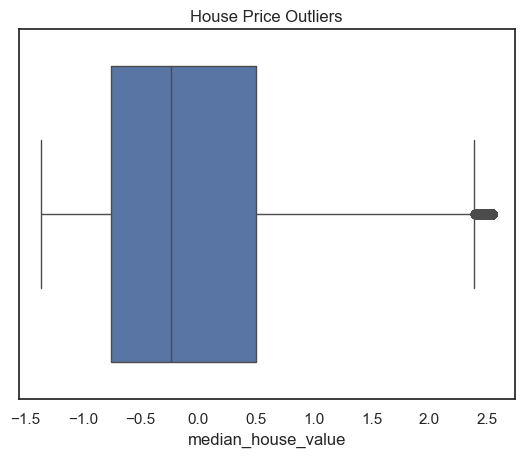

In [44]:
sns.boxplot(x=df['median_house_value'])
plt.title("House Price Outliers")
plt.show()

#### Insights
Data is Fairly Centered
- Median is around 0
- Because your data is standardized

Presence of Outliers (Right Side 2.5 )
- These are high-value houses
- There are some high-value outliers, indicating expensive properties beyond the typical range.

Slight Right Skew
- More spread on the right side
- A few very expensive houses pull the distribution
- The distribution shows slight positive skewness due to higher-value properties